# Test Model Performance — WC002 (biome placement extraction)

Runs the *same* extraction prompt + Pydantic schema architecture as
`tests/WC002_biome_placement/placement_check.py` (the second test under
`tests/`), against a hand-edited list of models, **with no `max_tokens`
cap**, to see how each one actually behaves: prompt/completion/reasoning/
answer token usage, latency, and reasoning quality — before deciding what
cap (if any) is safe for real harness runs.

Edit `MODELS` below and re-run. Every run appends a fresh, timestamped
JSON file to `data/` for later EDA — nothing is overwritten between runs.

### The output generated from this notebook would be latency, reasoning tokens, and the actual output for the biome placement extraction. The final output for this test is an elevation graph, which is being generated by these LLMs. Furthermore, there is a rule-based, deterministic logic placed inside the check itself, which is not present over here but present in the mean test case. This logic would check the adjacency nodes for the graph and score them accordingly.

In [1]:
from __future__ import annotations

import importlib.util
import json
import os
import queue
import sys
import threading
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime, timezone
from pathlib import Path

from dotenv import load_dotenv
from langchain_openrouter import ChatOpenRouter

load_dotenv()

True

In [2]:
def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    raise RuntimeError("could not find repo root (no pyproject.toml found upward)")


REPO_ROOT = _find_repo_root(Path.cwd())
TEST_DIR_NAME = "WC002_biome_placement"  # the second test under tests/ — this notebook mirrors its architecture
HTML_PATH = REPO_ROOT / "dry_runs" / "inputs" / "deepseek-v4-pro" / "world.html"  # edit to point at a different world.html

# Dynamically import placement_check.py by file path (same technique as
# harness/loader.py) so the schema/labels below are *reused*, not
# reimplemented — this notebook can't silently drift from what the real
# check actually grades against.
PLACEMENT_CHECK_PATH = REPO_ROOT / "tests" / TEST_DIR_NAME / "placement_check.py"
spec = importlib.util.spec_from_file_location("placement_check", PLACEMENT_CHECK_PATH)
placement_check = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = placement_check
spec.loader.exec_module(placement_check)

ExtractedGraph = placement_check.ExtractedGraph
BIOME_LABELS = placement_check.BIOME_LABELS
OPENROUTER_BASE_URL = placement_check.OPENROUTER_BASE_URL

print("repo root:", REPO_ROOT)
print("html path:", HTML_PATH, "exists:", HTML_PATH.exists())

repo root: /Users/krish/Workspace/worldbench
html path: /Users/krish/Workspace/worldbench/dry_runs/inputs/deepseek-v4-pro/world.html exists: True


In [3]:
def build_prompt(html_path: Path) -> str:
    """Same prompt text as placement_check.extract_graph — duplicated here
    (not imported) since it's inlined in that function rather than exposed
    as its own callable. Keep this in sync by hand if that prompt changes."""
    text = Path(html_path).read_text(encoding="utf-8", errors="ignore")
    biome_list = "\n".join(f"- {bid}: {label}" for bid, label in BIOME_LABELS.items())
    return (
        "This is the source of a procedurally generated Three.js floating-island "
        "scene. It contains exactly these 10 biomes (id: label):\n"
        f"{biome_list}\n\n"
        "For each biome, report which other biomes (by id) it is directly adjacent "
        "to / touches in the generated terrain, citing the specific evidence in the "
        "source you based that on (a coordinate, a comment, a generation-order "
        "clue, an adjacency implied by a fill/flood algorithm). Then report a single "
        "global ordering of all 10 biome ids from highest elevation/altitude to "
        "lowest, based on actual height/elevation values or generation logic in the "
        "source — not the biomes' typical real-world elevation.\n\n"
        f"Source:\n{text}"
    )


PROMPT = build_prompt(HTML_PATH)
print(f"prompt length: {len(PROMPT)} chars")

prompt length: 56347 chars


In [4]:
# Edit freely — 3-4 OpenRouter model ids to compare.
MODELS = [
    "nvidia/nemotron-3.5-lightning:free",
    "nvidia/nemotron-3-ultra-550b-a55b:free",
    "nvidia/nemotron-3-nano-30b-a3b:free",
    "nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free",
    "google/gemma-4-26b-a4b-it:free",
    "google/gemma-4-31b-it:free",
    "openrouter/free",
    "liquid/lfm-2.5-2.6b:free"
]

REQUEST_TIMEOUT_S = 600  # hard wall-clock deadline per model — the only ceiling left once max_tokens is removed

In [5]:
def _reasoning_from_details(details) -> str | None:
    if not details:
        return None
    parts: list[str] = []
    for block in details if isinstance(details, list) else [details]:
        if isinstance(block, dict):
            text = block.get("text") or block.get("summary") or block.get("content")
            if text:
                parts.append(str(text))
        elif isinstance(block, str):
            parts.append(block)
    return "\n".join(parts) or None


def _extract_reasoning_text(raw) -> str | None:
    """Prefer ChatOpenRouter content_blocks; fall back to OpenAI-compat kwargs."""
    blocks = getattr(raw, "content_blocks", None) or []
    from_blocks = [
        str(b.get("reasoning") or b.get("text") or "")
        for b in blocks
        if isinstance(b, dict) and b.get("type") == "reasoning"
    ]
    joined = "\n".join(p for p in from_blocks if p)
    if joined:
        return joined

    kwargs = raw.additional_kwargs or {}
    text = kwargs.get("reasoning") or kwargs.get("reasoning_content")
    if isinstance(text, str) and text.strip():
        return text
    from_details = _reasoning_from_details(kwargs.get("reasoning_details"))
    if from_details:
        return from_details
    content = raw.content
    if isinstance(content, list):
        parts = []
        for block in content:
            if isinstance(block, dict) and block.get("type") in (
                "reasoning",
                "thinking",
                "reasoning_content",
            ):
                parts.append(str(block.get("reasoning") or block.get("thinking") or block.get("text") or ""))
        joined = "\n".join(p for p in parts if p)
        if joined:
            return joined
    return None


def _json_safe(obj):
    """Recursively coerce LangChain/Pydantic objects into JSON-serializable data."""
    if obj is None or isinstance(obj, (str, int, float, bool)):
        return obj
    if isinstance(obj, BaseException):
        return {"type": type(obj).__name__, "message": str(obj)}
    if hasattr(obj, "model_dump"):
        return _json_safe(obj.model_dump())
    if isinstance(obj, dict):
        return {str(k): _json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_json_safe(v) for v in obj]
    return str(obj)


def run_model(model: str, prompt: str, timeout_s: float = REQUEST_TIMEOUT_S) -> dict:
    """Call one model with no max_tokens cap, timing it and pulling every
    token-usage/reasoning field the API returns. Mirrors
    placement_check.extract_graph()'s hard-timeout pattern (daemon thread +
    polling loop) since request_timeout alone is only a soft idle-read
    timeout that a trickling free-tier stream can dodge."""
    api_key = os.environ.get("OPENROUTER_API_KEY")
    if not api_key:
        raise RuntimeError("OPENROUTER_API_KEY not set (see .env.example)")

    client = ChatOpenRouter(
        model=model,
        openrouter_api_key=api_key,
        temperature=0,
        max_tokens=None,  # deliberately no cap — that's the point of this notebook
        request_timeout=timeout_s,
        max_retries=1,
        reasoning={"exclude": False},
    )
    llm = client.with_structured_output(ExtractedGraph, include_raw=True)

    result_queue: queue.Queue = queue.Queue(maxsize=1)

    def _call():
        try:
            result_queue.put(("ok", llm.invoke(prompt)))
        except Exception as e:
            result_queue.put(("error", e))

    t0 = time.monotonic()
    worker = threading.Thread(target=_call, daemon=True)
    worker.start()
    while worker.is_alive():
        if time.monotonic() - t0 >= timeout_s:
            return {
                "model": model,
                "success": False,
                "error": f"timed out after {timeout_s}s, no response",
                "latency_s": round(time.monotonic() - t0, 1),
            }
        worker.join(timeout=10)
    latency_s = round(time.monotonic() - t0, 1)

    status, payload = result_queue.get()
    if status == "error":
        return {"model": model, "success": False, "error": str(payload), "latency_s": latency_s}

    raw, parsed, parsing_error = payload["raw"], payload["parsed"], payload["parsing_error"]
    usage = (raw.response_metadata or {}).get("token_usage", {}) or {}
    um = getattr(raw, "usage_metadata", None) or {}
    completion_details = usage.get("completion_tokens_details", {}) or {}
    prompt_details = usage.get("prompt_tokens_details", {}) or {}
    reasoning_tokens = (
        completion_details.get("reasoning_tokens")
        or (um.get("output_token_details") or {}).get("reasoning")
        or 0
    )
    completion_tokens = usage.get("completion_tokens")
    if completion_tokens is None:
        completion_tokens = um.get("output_tokens")
    prompt_tokens = usage.get("prompt_tokens")
    if prompt_tokens is None:
        prompt_tokens = um.get("input_tokens")
    total_tokens = usage.get("total_tokens")
    if total_tokens is None:
        total_tokens = um.get("total_tokens")
    cached_tokens = prompt_details.get("cached_tokens") or (um.get("input_token_details") or {}).get("cache_read")
    answer_tokens = (completion_tokens - reasoning_tokens) if completion_tokens is not None else None
    reasoning_text = _extract_reasoning_text(raw)

    return {
        "model": model,
        "success": parsing_error is None and parsed is not None,
        "error": str(parsing_error) if parsing_error else None,
        "latency_s": latency_s,
        "finish_reason": (raw.response_metadata or {}).get("finish_reason"),
        "prompt_tokens": prompt_tokens,
        "cached_tokens": cached_tokens,
        "completion_tokens": completion_tokens,
        "reasoning_tokens": reasoning_tokens,
        "answer_tokens": answer_tokens,
        "total_tokens": total_tokens,
        "reasoning_text": reasoning_text,
        "reasoning_chars": len(reasoning_text) if reasoning_text else 0,
        "num_nodes_extracted": len(parsed.nodes) if parsed else None,
        # full llm.invoke() return — parsed is the graded answer; raw is the wire message
        "invoke": _json_safe(payload),
        "parsed": _json_safe(parsed),
        "raw_message": _json_safe(raw),
        "parsing_error": _json_safe(parsing_error),
    }

In [6]:
run_ts = datetime.now(timezone.utc).isoformat()


def _run_one(model: str) -> dict:
    print(f"running {model} ...")
    r = run_model(model, PROMPT)
    r["timestamp"] = run_ts
    r["html_path"] = str(HTML_PATH)
    r["test_dir_name"] = TEST_DIR_NAME
    print(
        f"  {model}: success={r.get('success')} latency={r.get('latency_s')}s "
        f"completion={r.get('completion_tokens')} reasoning={r.get('reasoning_tokens')} "
        f"error={r.get('error')}"
    )
    return r


results: list[dict] = []
with ThreadPoolExecutor(max_workers=len(MODELS)) as executor:
    futures = [executor.submit(_run_one, model) for model in MODELS]
    for future in as_completed(futures):
        results.append(future.result())

# keep MODELS order for downstream EDA
_model_order = {m: i for i, m in enumerate(MODELS)}
results.sort(key=lambda r: _model_order[r["model"]])

results

running nvidia/nemotron-3.5-lightning:free ...
running nvidia/nemotron-3-ultra-550b-a55b:free ...
running nvidia/nemotron-3-nano-30b-a3b:free ...
running nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free ...
running google/gemma-4-26b-a4b-it:free ...
running google/gemma-4-31b-it:free ...
running openrouter/free ...
running liquid/lfm-2.5-2.6b:free ...
  nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free: success=False latency=1.8s completion=None reasoning=None error=Provider returned error
  google/gemma-4-31b-it:free: success=False latency=3.9s completion=None reasoning=None error=Provider returned error
  openrouter/free: success=False latency=26.8s completion=None reasoning=None error=Rate limit exceeded: free-models-per-min. 
  liquid/lfm-2.5-2.6b:free: success=False latency=36.2s completion=None reasoning=None error=Rate limit exceeded: free-models-per-min. 
  nvidia/nemotron-3-ultra-550b-a55b:free: success=False latency=42.7s completion=None reasoning=None error=Rate limit exc

[{'model': 'nvidia/nemotron-3.5-lightning:free',
  'success': False,
  'error': 'The read operation timed out',
  'latency_s': 163.3,
  'timestamp': '2026-08-13T04:48:07.020117+00:00',
  'html_path': '/Users/krish/Workspace/worldbench/dry_runs/inputs/deepseek-v4-pro/world.html',
  'test_dir_name': 'WC002_biome_placement'},
 {'model': 'nvidia/nemotron-3-ultra-550b-a55b:free',
  'success': False,
  'error': 'Rate limit exceeded: free-models-per-min. ',
  'latency_s': 42.7,
  'timestamp': '2026-08-13T04:48:07.020117+00:00',
  'html_path': '/Users/krish/Workspace/worldbench/dry_runs/inputs/deepseek-v4-pro/world.html',
  'test_dir_name': 'WC002_biome_placement'},
 {'model': 'nvidia/nemotron-3-nano-30b-a3b:free',
  'success': False,
  'error': 'The read operation timed out',
  'latency_s': 204.7,
  'timestamp': '2026-08-13T04:48:07.020117+00:00',
  'html_path': '/Users/krish/Workspace/worldbench/dry_runs/inputs/deepseek-v4-pro/world.html',
  'test_dir_name': 'WC002_biome_placement'},
 {'mode

In [7]:
DATA_DIR = REPO_ROOT / "data"
DATA_DIR.mkdir(exist_ok=True)

run_timestamp = datetime.now(timezone.utc).strftime("%Y-%m-%dT%H-%M-%S")
out_path = DATA_DIR / f"test_model_performance_{run_timestamp}.json"

out_path.write_text(
    json.dumps(
        {
            "notebook": "test_model_performance",
            "test_dir_name": TEST_DIR_NAME,
            "html_path": str(HTML_PATH),
            "models": MODELS,
            "run_timestamp": run_timestamp,
            "results": results,
        },
        indent=2,
        default=str,
    )
)

print(f"saved {len(results)} results to {out_path}")

saved 8 results to /Users/krish/Workspace/worldbench/data/test_model_performance_2026-08-13T04-51-31.json


## Exploratory data analysis

In [ ]:
import pandas as pd

df = pd.DataFrame(results)
df_display = df[
    [
        "model", "success", "latency_s", "prompt_tokens", "completion_tokens",
        "reasoning_tokens", "answer_tokens", "total_tokens", "cached_tokens",
        "finish_reason", "error",
    ]
]
df_display

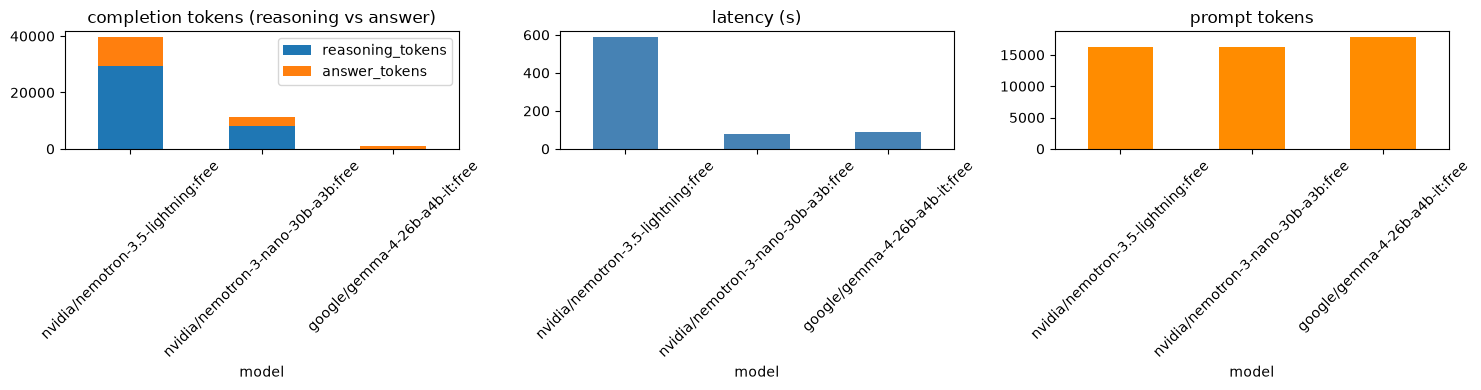

In [ ]:
import matplotlib.pyplot as plt

ok = df[df["success"]].set_index("model")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ok[["reasoning_tokens", "answer_tokens"]].plot.bar(stacked=True, ax=axes[0], title="completion tokens (reasoning vs answer)")
ok["latency_s"].plot.bar(ax=axes[1], title="latency (s)", color="steelblue")
ok["prompt_tokens"].plot.bar(ax=axes[2], title="prompt tokens", color="darkorange")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Reasoning text per model (qualitative read)

In [ ]:
for r in results:
    print("=" * 80)
    print(r["model"], "-", "OK" if r.get("success") else f"FAILED: {r.get('error')}")
    if r.get("reasoning_text"):
        print(f"--- reasoning ({r['reasoning_chars']} chars) ---")
        print(r["reasoning_text"][:3000])
    else:
        print("(no reasoning text captured)")

nvidia/nemotron-3.5-lightning:free - OK
--- reasoning (115749 chars) ---
Here's a thinking process:

1.  **Analyze User Input:**
   - User provides a source code (HTML/Three.js) for a procedurally generated floating-island scene.
   - There are exactly 10 biomes listed with IDs/labels:
     - mountains: Snow Mountains
     - forest: Snowy Conifer Forest
     - highlands: Highlands
     - jungle: Dense Jungle
     - swamp: Backwater Swamp
     - grove: Flowering Grove
     - grassland: Grassland Plateau
     - delta: Coastal Delta / Ocean
     - desert: Desert Basin
     - volcano: Volcano
   - User asks two things:
     a. For each biome, report which other biomes (by id) it is directly adjacent to / touches in the generated terrain, citing specific evidence from the source (coordinate, comment, generation-order clue, adjacency implied by fill/flood algorithm).
     b. Report a single global ordering of all 10 biome ids from highest elevation/altitude to lowest, based on actual height/